# R09-H67 - the hop-distance law: no traversal depth rescues a missing gold

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R09 graph topology round, flagship entry <br>
**Graph**: rebuilt CPAP graph (neo4j2), 28-probe gold set <br>

Measures the graph distance from production retrieval seeds to the entities that carry gold
evidence. H37 showed PPR specifically adds nothing over seeds+1-hop; this asks the general
question - could ANY traversal mechanism of any depth recover the golds that seeding misses?
The pre-registered claim: the distribution is bimodal (0-2 hops or disconnected), so
traversal-depth engineering is a dead lever and only seeding or densification can recover misses.

## Approach
1. **Carriers** - for each gold string, find carrier entities: nodes whose own render surface
   (name, description, prop_* values, attached propositions, relation lines) contains the gold
   per the H34 `present()` matcher
2. **Seeds** - replicate production seeding per probe (vector top-8 + proposition-derived seeds);
   vector top-16 recorded as the secondary budget (the H53 bar)
3. **Census** - multi-source BFS over the entity graph (currently-valid, non-SIMILAR_TO edges,
   undirected; SAME_AS counts as a hop - production render folds 1-2 SAME_AS hops into a node)
4. **Verdict** - against the bar: >=90% of reachable golds at <=2 hops AND <5% in the 3-5 band

## Outputs
- `reports/graph-census-r09h67-<stamp>.json` - per-gold distances, buckets, verdict
- In-notebook: hop-distance histogram, per-probe table

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env
import re  # evidence normalization
from collections import deque  # BFS

# third party
import yaml  # probe set
import matplotlib.pyplot as plt  # hop histogram
from pathlib import Path
from rich import print as rprint  # semantic output
from rich.progress import Progress  # census loop

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

# project
from knowledge_graph_foundry import Foundry, load_settings  # pipeline
from knowledge_graph_foundry.extraction import generate_embeddings  # Titan probe embedding
from knowledge_graph_foundry.graph.graphrag import vector_query  # seed channel
from knowledge_graph_foundry.graph.propositions import proposition_query  # seed channel
from knowledge_graph_foundry.models import Entity  # embedding probe wrapper

2026-07-06 21:47:07.791 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")  # 28 probes with gold evidence

settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k                        # production vector seeds (8)
TOP_K_WIDE = 16                                        # H53 budget bar
PROP_TOP_K = settings.graphrag.proposition_top_k       # proposition seeds per probe
VEC_INDEX = settings.graphrag.vector_index_name
PROP_INDEX = settings.graphrag.proposition_index_name
MAX_HOPS = 6                                           # census radius; beyond = unreachable

# pre-registered acceptance bar (experiments log, R09-H67)
BAR_NEAR_SHARE = 0.90   # >=90% of reachable golds at <=2 hops
BAR_MID_SHARE = 0.05    # <5% in the 3-5 hop band -> bimodal, dial closed

probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold]
  Neo4j: [cyan]{os.environ['NEO4J_URI']}[/cyan]

[bold]Seeding (production)[/bold]
  Vector top-k: [yellow]{TOP_K}[/yellow] [dim](wide budget {TOP_K_WIDE})[/dim]
  Proposition top-k: [yellow]{PROP_TOP_K}[/yellow]

[bold]Census[/bold]
  Max hops: [yellow]{MAX_HOPS}[/yellow]
  Probes: [yellow]{len(gold_probes)}[/yellow] with gold evidence

[bold]Acceptance bar[/bold]
  Confirmed: reachable golds at <=2 hops >= [yellow]{BAR_NEAR_SHARE}[/yellow] AND 3-5 band < [yellow]{BAR_MID_SHARE}[/yellow]
  Refuted: a material 3-5 hop band (deeper traversal is a real lever)
""")

Configuration
────────────────────────────────────────
Graph
  Neo4j: bolt://user-konrad.jelen-kgf-neo4j2:7687

Seeding (production)
  Vector top-k: 8 (wide budget 16)
  Proposition top-k: 8

Census
  Max hops: 6
  Probes: 24 with gold evidence

Acceptance bar
  Confirmed: reachable golds at <=2 hops >= 0.9 AND 3-5 band < 0.05
  Refuted: a material 3-5 hop band (deeper traversal is a real lever)

## Graph snapshot and carrier surfaces

One pass loads every entity's render surface (name, description, prop_* values, attached
proposition texts, relation lines) and the currently-valid non-SIMILAR_TO edge list. The
carrier surface replicates what production would render if the node entered the context,
so "carrier" means: retrieving this node makes the gold visible.

In [3]:
with Foundry(settings) as f:
    with f.driver.session() as s:
        ents = s.run(
            "MATCH (e:Entity) RETURN e.id AS id, e.name AS name, "
            "e.description AS description, properties(e) AS props"
        ).data()
        prop_texts = s.run(
            "MATCH (p:Proposition)-[:ABOUT]->(e:Entity) "
            "RETURN e.id AS eid, p.text AS text"
        ).data()
        edges = s.run(
            "MATCH (a:Entity)-[r]-(b:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id "
            "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"
        ).data()

by_ent_props = {}
for row in prop_texts:
    by_ent_props.setdefault(row["eid"], []).append(row["text"])

rel_lines = {}
for e_ in edges:
    rel_lines.setdefault(e_["a"], []).append(e_["rel"])
    rel_lines.setdefault(e_["b"], []).append(e_["rel"])

names = {r["id"]: r["name"] for r in ents}
surface = {}
for r in ents:
    spec = {k.removeprefix("prop_"): v for k, v in r["props"].items() if k.startswith("prop_")}
    surface[r["id"]] = " ".join([
        r["name"] or "", r["description"] or "",
        json.dumps(spec, default=str),
        " ".join(by_ent_props.get(r["id"], [])),
    ])

# relation render lines ("REL -> neighbor name") attach the line to BOTH endpoints
adj = {}
for e_ in edges:
    adj.setdefault(e_["a"], set()).add(e_["b"])
    adj.setdefault(e_["b"], set()).add(e_["a"])
for e_ in edges:
    surface[e_["a"]] += f" {e_['rel']} {names.get(e_['b'], '')}"
    surface[e_["b"]] += f" {e_['rel']} {names.get(e_['a'], '')}"

rprint(
    f"entities: [yellow]{len(ents)}[/yellow]  edges: [yellow]{len(edges)}[/yellow]  "
    f"propositions attached: [yellow]{len(prop_texts)}[/yellow]"
)

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=41, offset=40>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 40, 'line': 1, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (a:Entity)-[r]-(b:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"


entities: 2798  edges: 3905  propositions attached: 19654

## Gold carriers

The H34 iteration-3 matcher (normalized substring -> unit-stripped numeric skeleton ->
value-token majority -> 0.6 content-word overlap) decides whether a gold string is present
on an entity's surface. Golds with zero carriers are extraction gaps - they cannot be
retrieved at ANY distance and are excluded from the hop law (reported separately).

In [4]:
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())


def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)


_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"


def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6


norm_surface = {eid: _norm(t) for eid, t in surface.items()}

carriers = {}   # (pid, gold) -> [entity ids]
orphans = []    # golds with no carrier at all
for p in gold_probes:
    for g in p["gold_evidence"]:
        c = [eid for eid, t in norm_surface.items() if present(g, t)]
        carriers[(p["id"], g)] = c
        if not c:
            orphans.append((p["id"], g))

n_golds = sum(len(p["gold_evidence"]) for p in gold_probes)
rprint(
    f"golds: [yellow]{n_golds}[/yellow]  carried: [green]{n_golds - len(orphans)}[/green]  "
    f"orphan (no carrier entity): [red]{len(orphans)}[/red]"
)
for pid, g in orphans:
    rprint(f"  [dim]{pid}[/dim] [red]orphan:[/red] {g[:90]}")

golds: 33  carried: 33  orphan (no carrier entity): 0

## Seeds and multi-source BFS

Production seeding per probe (Titan probe embedding -> vector top-8 -> proposition top-8
adding their linked entities), then one multi-source BFS per probe over the undirected
valid-edge adjacency. Distance of a gold = min over its carriers of the BFS distance;
0 means a seed itself carries the gold.

In [5]:
def bfs(sources, adj, max_hops):
    dist = {s_: 0 for s_ in sources}
    q = deque(sources)
    while q:
        u = q.popleft()
        if dist[u] >= max_hops:
            continue
        for v in adj.get(u, ()):
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist


census = []
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("hop census", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        emb = generate_embeddings([probe_e], settings.embeddings)[0].embedding

        vec16 = vector_query(f.driver, emb, VEC_INDEX, top_k=TOP_K_WIDE)
        vec_ids = [s_["id"] for s_ in vec16[:TOP_K]]
        prop_hits = proposition_query(f.driver, emb, PROP_INDEX, top_k=PROP_TOP_K)
        prop_ids = [eid for h in prop_hits for eid in h["entity_ids"] if eid not in vec_ids]

        seeds_prod = [i for i in vec_ids + prop_ids if i in surface]
        seeds_wide = [i for i in {s_["id"] for s_ in vec16} | set(prop_ids) if i in surface]

        d_prod = bfs(seeds_prod, adj, MAX_HOPS)
        d_wide = bfs(seeds_wide, adj, MAX_HOPS)

        for g in p["gold_evidence"]:
            c = carriers[(p["id"], g)]
            if not c:
                continue
            census.append({
                "probe": p["id"], "gold": g[:70], "n_carriers": len(c),
                "d_prod": min((d_prod[x] for x in c if x in d_prod), default=None),
                "d_wide": min((d_wide[x] for x in c if x in d_wide), default=None),
            })
        progress.advance(task)

rprint(f"[green]census complete[/green] - {len(census)} carried golds across {len(gold_probes)} probes")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-06 21:47:14.915 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 21:47:14.918 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-06 21:47:15.209 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 21:47:15.211 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

...

2026-07-06 21:47:20.907 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 21:47:20.910 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-06 21:47:21.163 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 21:47:21.165 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

census complete - 33 carried golds across 24 probes

## Distribution, figure and verdict

Buckets: hop 0 (a seed carries the gold), 1, 2, the 3-5 band, and unreachable within the
census radius. The bar reads on the PRODUCTION seed budget; the wide (16-seed) budget shows
how the distribution shifts with the H53 lever.

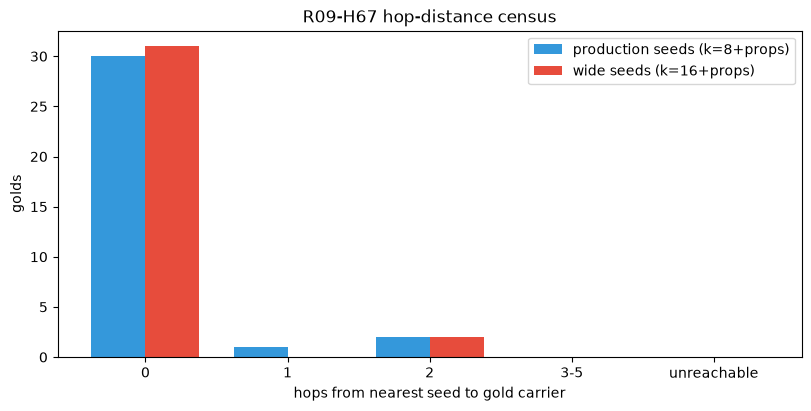

Hop-distance law
────────────────────────────────────────
  Buckets (production): {'0': 30, '1': 1, '2': 2}
  Buckets (wide k=16):  {'0': 31, '2': 2}
  Reachable golds at <=2 hops: 1.000 (bar >= 0.9)
  3-5 hop band share: 0.000 (bar < 0.05)
  Unreachable: 0 of 33
  Verdict: CONFIRMED

saved ../reports/graph-census-r09h67-20260706-194721.json

In [6]:
def bucket(d):
    if d is None:
        return "unreachable"
    if d <= 2:
        return str(d)
    return "3-5"


rows = {"prod": {}, "wide": {}}
for c in census:
    for k, key in (("prod", "d_prod"), ("wide", "d_wide")):
        b = bucket(c[key])
        rows[k][b] = rows[k].get(b, 0) + 1

order = ["0", "1", "2", "3-5", "unreachable"]
total = len(census)
reach_prod = sum(rows["prod"].get(b, 0) for b in ["0", "1", "2", "3-5"])
near_share = sum(rows["prod"].get(b, 0) for b in ["0", "1", "2"]) / max(reach_prod, 1)
mid_share = rows["prod"].get("3-5", 0) / max(reach_prod, 1)

verdict = (
    "CONFIRMED" if near_share >= BAR_NEAR_SHARE and mid_share < BAR_MID_SHARE
    else "REFUTED" if mid_share >= BAR_MID_SHARE else "INCONCLUSIVE"
)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
x = range(len(order))
w = 0.38
ax.bar([i - w / 2 for i in x], [rows["prod"].get(b, 0) for b in order], w,
       color="#3498DB", label=f"production seeds (k={TOP_K}+props)")
ax.bar([i + w / 2 for i in x], [rows["wide"].get(b, 0) for b in order], w,
       color="#E74C3C", label=f"wide seeds (k={TOP_K_WIDE}+props)")
ax.set_xticks(list(x), order)
ax.set(xlabel="hops from nearest seed to gold carrier", ylabel="golds",
       title="R09-H67 hop-distance census")
ax.legend()
plt.show()

deep = [c for c in census if c["d_prod"] is not None and c["d_prod"] >= 3]
unreach = [c for c in census if c["d_prod"] is None]
rprint(f"""[bold cyan]Hop-distance law[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Buckets (production): {dict(sorted(rows['prod'].items(), key=lambda kv: order.index(kv[0])))}
  Buckets (wide k=16):  {dict(sorted(rows['wide'].items(), key=lambda kv: order.index(kv[0])))}
  Reachable golds at <=2 hops: [yellow]{near_share:.3f}[/yellow] [dim](bar >= {BAR_NEAR_SHARE})[/dim]
  3-5 hop band share: [yellow]{mid_share:.3f}[/yellow] [dim](bar < {BAR_MID_SHARE})[/dim]
  Unreachable: [yellow]{len(unreach)}[/yellow] of {total}
  Verdict: [{'green' if verdict == 'CONFIRMED' else 'red'}]{verdict}[/]
""")
for c in deep:
    rprint(f"  [dim]{c['probe']}[/dim] d={c['d_prod']} {c['gold']}")
for c in unreach:
    rprint(f"  [dim]{c['probe']}[/dim] [red]unreachable:[/red] {c['gold']}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"graph-census-r09h67-{stamp}.json"
out.write_text(json.dumps({
    "golds_total": n_golds, "carried": total, "orphans": [list(o) for o in orphans],
    "buckets_prod": rows["prod"], "buckets_wide": rows["wide"],
    "near_share": near_share, "mid_share": mid_share, "verdict": verdict,
    "census": census,
}, indent=2, default=str))
rprint("saved", str(out))